# Вычислительная математика
## 5.1 УРЧП. Общие факты. Эллиптический тип

Содержание семинара:

- __Общая формулировка УРЧП__
    - Линейные УРЧП. Классификация
    - Об отличиях типов
- __2D Уравнение Пуассона. Эллиптические уравнения__
    - Прямой способ
    - Сведение к __уравнению теплопроводности__
- __Сходимость численных схем__
    - Сходимость = Аппроксимация + Устойчивость
    - Аппроксимация
    - Признаки устойчивости:
        - Признак фон Неймана
- __Домашнее задание__

## Общая формулировка УРЧП
### Линейные УРЧП. Классификация

__Определение.__ __Линейное УРЧП__ от двух переменных это уравнение вида

$$
A(x, y) \frac{\partial^2 u}{\partial x^2}+B(x, y) \frac{\partial^2 u}{\partial x \partial y}+C(x, y) \frac{\partial^2 u}{\partial y^2}+D(x, y) \frac{\partial u}{\partial x}+E(x, y) \frac{\partial u}{\partial y}+F(x, y) u+G(x, y)=0
$$

что эквивалентно следующей записи

$$
A(x, y) \frac{\partial^2 u}{\partial x^2}+B(x, y) \frac{\partial^2 u}{\partial x \partial y}+C(x, y) \frac{\partial^2 u}{\partial y^2}=\hat{\mathbf{L}} u
$$

Цель - __найти $u(x,y)$ с заданными граничными условиями__.

__Примечание.__ Если бы какие-то из коэффициентов зависели бы ещё дополнительно от $u$, $\frac{\partial u}{\partial x}$ или $\frac{\partial u}{\partial y}$, то уравнение называлось бы __квазилинейным__.

Относительно $A(x, y), B(x, y)$ и $C(x, y)$ можно подвести следующую классификацию УРЧП:

$$
\begin{array}{|c|c|c|}
\hline \text { Classification } & \text { Condition } & \text { Example of PDE } \\
\hline \text { Parabolic } & B^2-4 A C=0 & \text { Heat equation } \\
\hline \text { Hyperbolic } & B^2-4 A C>0 & \text { Wave equation } \\
\hline \text { Elliptic } & B^2-4 A C<0 & \text { Laplace equation } \\
\hline \begin{array}{c}
\text { Mix Type } \\
\text { (parabolic/hyperbolic/elliptic) }
\end{array} & \begin{array}{c}
\text { Satisfied all/more than one of the } \\
\text { above conditions }
\end{array} & \begin{array}{c}
\text { Heat/Wave/Laplace/Poisson } \\
\text { equation }
\end{array} \\
\hline
\end{array}
$$

__Примечание.__ Классификация __локальна__, т.к. коэффициенты зависят от точки плоскости в которой мы сейчас находимся, и знак Condition может меняться в рассматриваемой области - отсюда и смешанный тип.

__Примечание.__ Названия типов формально берутся от квадратичной формы характеристического уравнения. Все типа существенно различаются по свойствам, что приводит к их отдельному рассмотрению. В частности, решения эллиптического уравнения всегда гладкие, тогда как решения гиперболических уравнений этим свойством не обладают.

__Примечание.__ В случае бОльшего числа переменных, типы сохраняются:

$$\sum_{i=1}^n \sum_{j=1}^n a_{i, j} \frac{\partial^2 u}{\partial x_i \partial x_j} \; + \; F(u,\; \frac{\partial u}{\partial x_1},\; \frac{\partial u}{\partial x_2}, \cdots, \; \frac{\partial u}{\partial x_n})=0$$

- __Elliptic__: All eigenvalues $a_{i,j}$ have the same sign. [Laplace-Eq.]
- __Parabolic__: One eigenvalue is zero. [Diffusion-Eq.]
- __Hyperbolic__: One eigenvalue has opposite sign. [Wave-Eq.]
- __Ultrahyperbolic__: More than one positive and negative eigenvalue.
- __Mixed__

### Об отличиях типов

__Эллиптический тип__
- Обычно нет временной зависимости - несколько пространственных координат. Нет эволюции во времени - процесс __стационарный__.
- Решаются как краевые задачи при заданных краевых условиях.
- Решения гладкие, если позволяют краевые условия.

Примеры:

- Уравнение Пуассона (Лапласа при $f=0$):
$$
\sum_{i=1}^n \frac{\partial^2}{\partial x_i^2} u(x)=f(x)
$$

__Параболический тип__
- Явный __эволюционный во времени__ процесс. См. характеристики для понимания. Нулевое собственное число отвечает времени.
- Явная зависимость от времени.
- Решаются как при заданных начальных условиях, так и при краевых.
- "Негладкости" и "разрывы" возможны, но __сглаживаются__ со временем.

Примеры:

- Уравнение теплопроводности (диффузии)

$$
\frac{\partial u}{\partial t}-a^2 \Delta u=f(\mathbf{r}, t)
$$

- Уравнение анизотропной диффузии (квазилинейное - страшно, да?)

$$
\frac{\partial u(\mathbf{r}, t)}{\partial t}=\sum_{i=1}^3 \sum_{j=1}^3 \frac{\partial}{\partial x_i}\left[D_{i j}(u, \mathbf{r}) \frac{\partial u(\mathbf{r}, t)}{\partial x_j}\right]
$$

__Гиперболический тип__

- Также эволюционный во времени процесс, но можно страктовать отрицательное с.з. как обратное время.
- Решаются как при заданных начальных условиях, так и при краевых.
- "Негладкости" и "разрывы" могут __появляться__ в ходе эволюции (ударная волна).

Примеры:

- Волновое уравнение

$$
\left(\Delta-\frac{1}{c^2} \frac{\partial^2}{\partial t^2}\right) u=0
$$

__Примечание.__ Отличия могут показаться несущественными, но на практике они столь велики, что решения каждого типа считается отдельной областью. В этом семинаре начнём с эллиптического типа, чтобы пока не закапываться в эволюционные процессы и разрывы.

## 2D Уравнение Пуассона. Подход "в лоб"

Мы хотим решить уравнение Пуассона:

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = f(x, y)$$

в $[0,1] \times [0,1]$ - квадратная область с граничными условиями

$$u(x,0) = x, \quad u(x,1) = x - 1, \quad u(0,y) = -y, \quad u(1,y) = 1 - y.$$

__Примечание.__ Даже если область другая, можем произвести замену координат к квадрату. На тип уравнения повлиять не должно (если не выпендриваться).

Дискретизуем производные. Возьмём формулы второго порядка аппроксимации по каждой из осей.

$$
\frac{u_{i-1, j}-2 u_{i, j}+u_{i+1, j}}{h^2}+\frac{u_{i, j-1}-2 u_{i, j}+u_{i, j+1}}{h^2}=f_{i j}
$$

Отсюда получаем уравнение на центральную точку (т.к. знаем края логично двигаться в центр)

$$
u_{i, j}=\frac{1}{4}\left(u_{i+1, j}+u_{i-1, j}+u_{i, j+1}+u_{i, j-1}-h^2 f\left(x_i, y_j\right) \right)
$$

Решаем наш "диффур" на сетке $(i, j)$. При этом знаем все граничные точки на сетке, и есть уравнение связи точек на "кресте" (т.н. шаблон крест).

__Примечание.__ Зная 4 точки из "креста", можно найти пятую, выразив из уравнения. При другой дискретизации производных получили бы другие шаблоны.

<img src="https://cdn.mathpix.com/snip/images/-UXjZDVom7s7c5dIXtHLmEohWS_-GpjJxhKpLpartBQ.original.fullsize.png" width="300">


Такая схема обладает 2-м порядком аппроксимации (достаточно просто разложить по Тейлору вокруг точек $x_i$ и $y_j$ и убедиться, что дифференциальное уравнение выполняется с точностью $O(h^2)$).

Для решения задачи (определения всех внутренних точек, зная только краевые) можно составить большую СЛАУ на все внутренние точки. Грубо говоря, будем идти нашим крестом по всем внутренним точкам начиная с нижнего ряда и до верхнего по порядку. В каждом случае, будем запоминать, какая функциональная связь между коэффициентами. Когда дойдём до верхнего ряда, пойдём назад и "расшифруем" все пройдённые точки.

Звучит сложно, да? Это называется __прямой метод__. Объясним его подробнее.

### Прямой метод

Хотим свести дифференциальную задачу к дискретной, заданной в тензорном (дискретизованном) виде (__с учётом краевых условий__):

$$
L_{i,j,k,l}\cdot u_{k,l}=b_{i,j}
$$

Во всех "внутренних" точках квадрата оно имеет тот самый дискретизованный вид, который мы написали ранее:

$$
b_{i,j}=f_{i,j}, \quad i,j \in [1, \cdots,n-1]
$$

$$
L_{i,j,k,l}\cdot u_{k,l}=\frac{u_{i-1, j}-2 u_{i, j}+u_{i+1, j}}{h^2}+\frac{u_{i, j-1}-2 u_{i, j}+u_{i, j+1}}{h^2}, \quad i,j \in [1, \cdots,n-1]
$$

$$
L_{i,j,k,l}\cdot u_{k,l}=\frac{1}{h^2}\left(u_{i-1, j}+u_{i+1, j} +u_{i, j-1}+u_{i, j+1}\right)-\frac{4}{h^2}u_{i, j}, \quad i,j \in [1, \cdots,n-1]
$$

А тогда просто вспомнив, как работает сумма, для внутренних $i,j \in [1, \cdots,n-1]$ выполнено

$$
\left\{\begin{array}{l}
L_{i, j, i+1, j}=L_{i, j, i-1, j}=L_{i, j, i, j+1}=L_{i, j, i, j-1}=\frac{1}{h^2} \\
L_{i, j, i, j}=-\frac{4}{h^2} \\
L_{i, j, \text { other }}=0
\end{array}\right.
$$

Также в это тензорное уравнение мы хотим занести краевые условия. Достаточно следующего:

$$
b_{0,j}=\varphi_{\text{left}}(y_j)
$$

$$
L_{0, j, k, l}\cdot u_{k, l} = u_{0, j} 
$$

что эквивалентно

$$
\left\{\begin{array}{l}
L_{0, j, 0, j}=1 \\
L_{0, j, \text{other}}=0
\end{array}\right.
$$

Для остальных трёх краевых условий аналогично.

Теперь, когда мы определили все элементы $L_{i,j,k,l}$ и $b_{i,j}$, остаётся только решить тензорное уравнение относительно $u_{i,j}$:

$$
L_{i,j,k,l}\cdot u_{k,l}=b_{i,j}
$$

В этом могут помочь методы numpy ;).

In [14]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


def boundary(grid):
    x = np.linspace(0,1,len(grid))
    
    grid[0,:]  = -x
    grid[:,-1] = x-1
    grid[-1,:] = 1-x
    grid[:,0]  = x
    

def poisson_direct(gridsize, set_boundary):
    L = np.zeros(shape=(gridsize, gridsize, gridsize, gridsize),
                 dtype='d')
    
    b = np.zeros(shape=(gridsize, gridsize),
                 dtype='d')
    
    dx = 1.0 / (gridsize - 1)
    
    # discretized differential operator
    for i in range(1,gridsize-1):
        for j in range(1,gridsize-1):
            L[i,j,i-1,j] = L[i,j,i+1,j] = L[i,j,i,j-1] = L[i,j,i,j+1] = 1/dx**2
            L[i,j,i,j] = -4/dx**2
    
    # boundary conditions
    for i in range(0,gridsize):
        L[0,i,0,i] = L[-1,i,-1,i] = L[i,0,i,0] = L[i,-1,i,-1] = 1
    
    # set the boundary values on the right side
    set_boundary(b)
    
    return np.linalg.tensorsolve(L,b) 

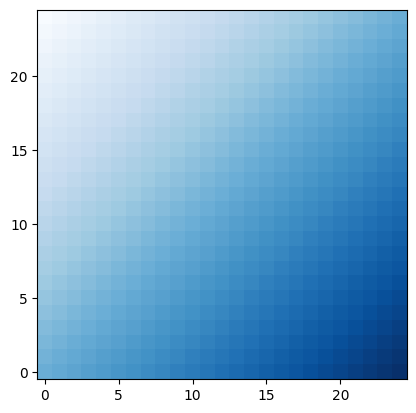

In [4]:
def showsol(sol):
    plt.imshow(sol.T,cmap=mpl.cm.Blues,interpolation='none',origin='lower')

sol = poisson_direct(25, boundary) # Сетка из 25 точек
showsol(sol)

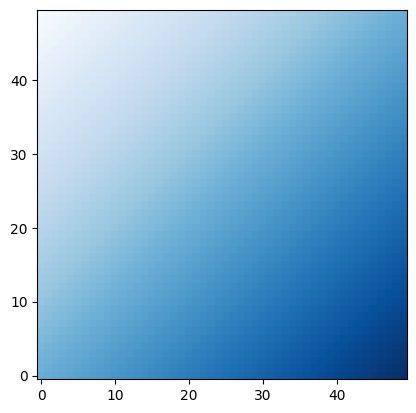

In [3]:
showsol(poisson_direct(50,boundary)) # Уменьшим сетку

### Итерационный метод (уравнение теплопроводности)

Вообще, прямой подход достаточно сложный - нужно обращать сильно разряженную матрицу. Можно решить эту же задачу __итерационно__.

На основе нашего уравнения Пуассона запишем параболическое __уравнение диффузии__ (технически, оно уже от трёх переменных - см. увеличенную классификацию):

$$
\frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}-f(x,y)
$$

Идея заключается в том, что на бесконечности по $t$ эволюция системы должна остановится (система достигнет равновесия), а тогда левая часть занулится и полученное состояние будет решением уравнения Пуассона в чистом виде. Стартовать при этом "казалось бы" можно из любой начальной конфигурации, отвечающей граничным условиям. Естественно, скорость сходимости будет зависеть от близости к истинному решению.

Дискретизуем правую часть как и раньше, а левую просто "производной-вперёд". Тогда получаем следующую реккуренту:

$$
u^{n+1}_{i,j} = u^{n}_{i,j} + \frac{\tau}{h^2}(u^{n}_{i+1,j} + u^{n}_{i-1,j} + u^{n}_{i,j+1} + u^{n}_{i,j-1} - 4u^n_{i,j})-\tau \cdot f_{i,j}
$$

Где нижние координаты отвечают за пространственную часть, а верхняя за временную. При этом начальный $u_{i,j}^{0}$ мы выбираем сами.

Насчёт порядка аппроксимации этой схемы см. ниже. Пока скажем, что он равен $O(\tau \cdot h^2 + \tau^2)$.

Получилась начальная + краевая задача, как и было оговорено кратко ранее.

Наибольший стабильный шаг по времени (оптимальный параметр) здесь будет $\tau = h^2/4$. Как такое получать для произвольной схемы обсудим ниже в признаках устойчивости. В этом случае,

$$
u^{n+1}_{i,j} = \frac{1}{4}(u^{n}_{i+1,j} + u^{n}_{i-1,j} + u^{n}_{i,j+1} + u^{n}_{i,j-1})-\frac{h^2}{4}\cdot f_{i,j}
$$

Видим, что каждой точке присваивается среднее арифметическое её соседей с поправкой на свободный член.

In [22]:
from numba import njit

@njit()
def boundary(grid):
    x = np.linspace(0,1,len(grid))
    
    grid[0,:]  = -x
    grid[:,-1] = x-1
    grid[-1,:] = 1-x
    grid[:,0]  = x


@njit()
def step(grid):
    newgrid = grid.copy()
    
    for i in range(1,newgrid.shape[0]-1):
        for j in range(1,newgrid.shape[1]-1):
            newgrid[i,j] = 0.25 * (newgrid[i,j+1] + newgrid[i,j-1] +
                                   newgrid[i+1,j] + newgrid[i-1,j])
    
    return newgrid


@njit() # Начальная случайная сетка
def initgrid(gridsize): 
    x = np.random.randn(gridsize,gridsize)
    boundary(x)
    
    return x

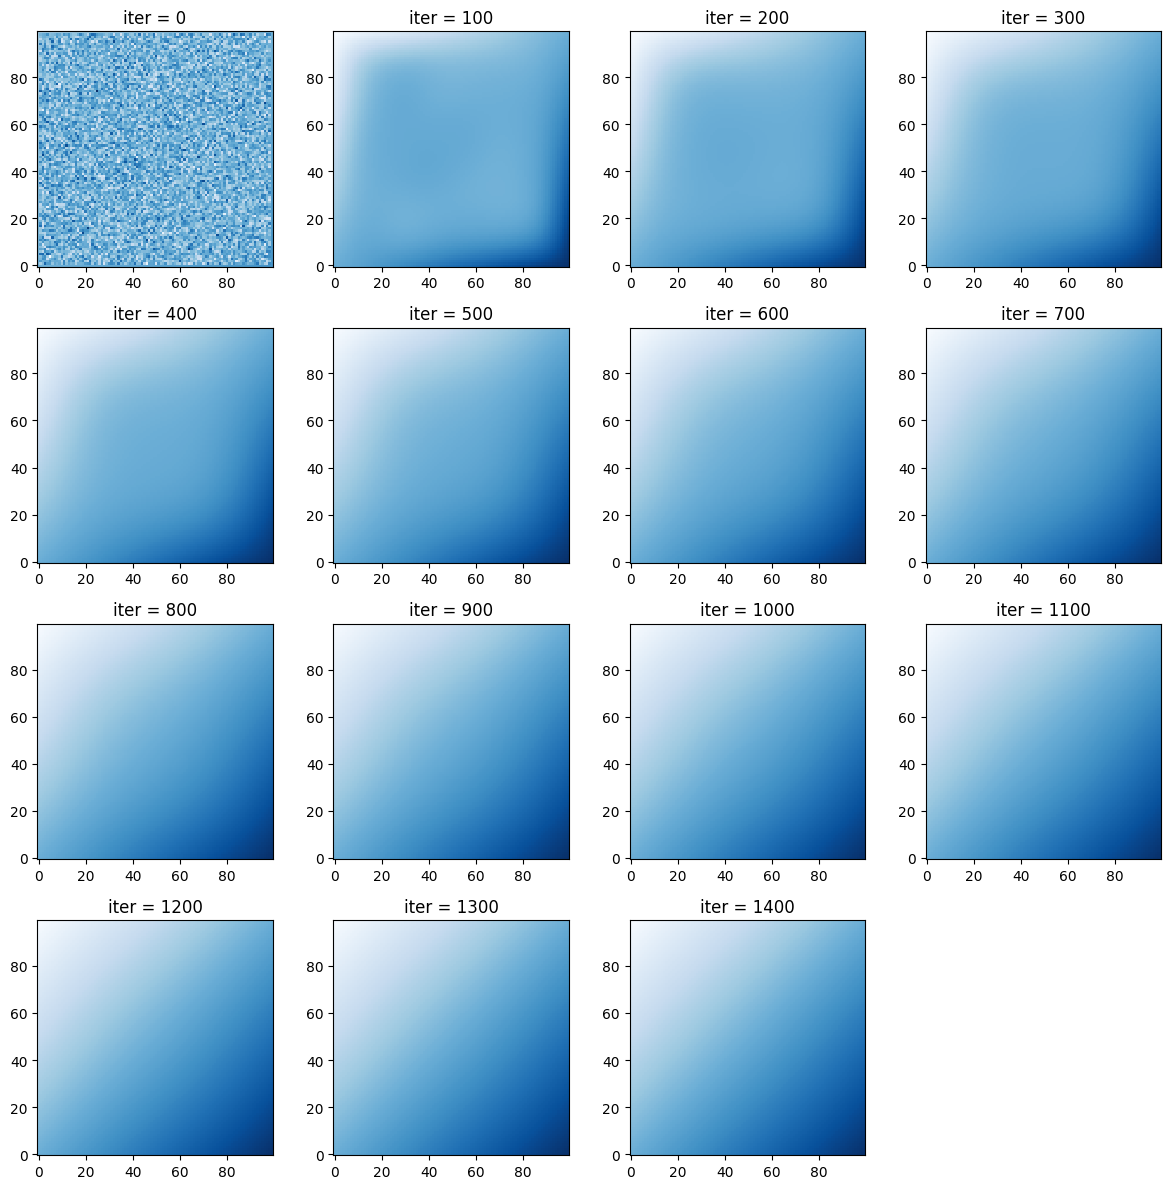

In [23]:
x = initgrid(100)

plt.figure(figsize=(12,12))

for i in range(1500):    
    if i % 100 == 0:
        plt.subplot(4,4,i//100+1)
        showsol(x)
        plt.title('iter = %s' % i)
    x = step(x)

plt.tight_layout()

Посмотрим на график отклонения от решения, полученного прямым методом

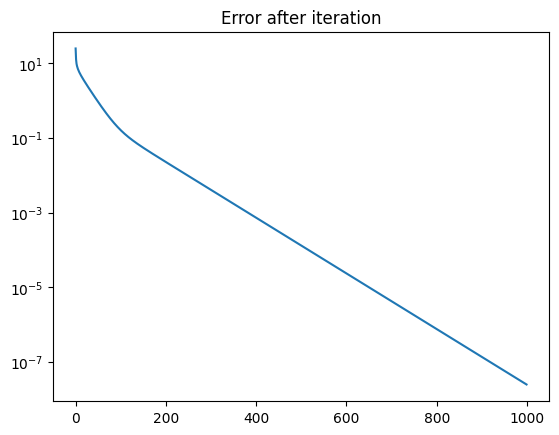

In [24]:
x = initgrid(25)
sol = poisson_direct(25, boundary)

err = []

for i in range(1000):    
    err.append((i,np.linalg.norm(x - sol)))
            
    x = step(x)

err = np.array(err)
    
plt.semilogy(err[:,0],err[:,1])
plt.title('Error after iteration');

## Сходимость численных схем

### Сходимость = Аппроксимация + Устойчивость

__Теорема.__ (Лакса-Рябенького-Филиппова). Пусть разностная задача аппроксимирует дифференциальную задачу на ее решении и устойчива. Тогда решение разностной задачи сходится к решению дифференциальной. 
Если аппроксимация имеет порядок $k$ по времени и порядок р по пространству, то и сходимость имеет те же порядки.

### Аппроксимация

В чистом виде переносится с задачи Коши с поправкой на несколько переменных. Таким образом можно ввести отдельные порядки аппроксимации по разным осям.

__Пример.__ Для разнообразия рассмотрим УРЧП первого порядка.

$$
\frac{\partial u}{\partial t} = \frac{\partial u}{\partial x} + f(x, t)
$$

относительно следующей разностной задачи:

$$
\frac{u^{n+1}_j-u^{n}_j}{\tau} = \frac{u^n_{j+1}-u^n_{j-1}}{h} + f^n_j
$$

Разложение в ряд Тейлора удобнее всего делать с помощью Wolfram или sympy

In [7]:
import sympy as sp

# Define the symbolic variables
f, x, t, h, tau = sp.symbols('f x t h tau')

# Define the symbolic function u(x,t)
u = sp.Function('u')(x,t)
f = sp.Function('f')(x,t)


# Define the finite difference scheme for u_t = u_x + f
ut = (u.subs(t, t+tau) - u) / tau
ux = (u.subs(x, x+h) - u.subs(x, x-h)) / (2*h)

# Define the Taylor series expansion of u(x+h,t+tau) and u(x-h,t+tau)
ut_series = sp.series(ut, tau, x0=0, n=4)
ux_series = sp.series(ux, h, x0=0, n=4)
ut_series - ux_series - f

Subs(Derivative(u(x, _xi_2), _xi_2), _xi_2, t) - Subs(Derivative(u(_xi_1, t), _xi_1), _xi_1, x) - f(x, t) + tau*Subs(Derivative(u(x, _xi_2), (_xi_2, 2)), _xi_2, t)/2 + tau**2*Subs(Derivative(u(x, _xi_2), (_xi_2, 3)), _xi_2, t)/6 + tau**3*Subs(Derivative(u(x, _xi_2), (_xi_2, 4)), _xi_2, t)/24 - h**2*Subs(Derivative(u(_xi_1, t), (_xi_1, 3)), _xi_1, x)/6 + O(tau**4) + O(h**4)

__Пример.__ Ну и для нашей разностной задачи для решения уравнения Пуассона итерационным методом

$$
u^{n+1}_{i,j} = u^{n}_{i,j} + \frac{\tau}{h^2}(u^{n}_{i+1,j} + u^{n}_{i-1,j} + u^{n}_{i,j+1} + u^{n}_{i,j-1} - 4u^n_{i,j})-\tau \cdot f_{i,j}
$$

In [8]:
import sympy as sp

# Define the symbolic variables
f, x, y, t, h, tau = sp.symbols('f x y t h tau')

# Define the symbolic function u(x,t)
u = sp.Function('u')(x,y,t)
f = sp.Function('f')(x,y)

# Define the finite difference scheme for u_t = u_x + f

u_100 = u.subs(x, x+h)
u_m00 = u.subs(x, x-h)

u_010 = u.subs(y, y+h)
u_0m0 = u.subs(y, y-h)

u_001 = u.subs(t, t+tau)

diff_scheme = -u_001 + u + tau/h**2*(u_100+u_m00+u_010+u_0m0-4*u) - tau*f

# Taylor

diff_scheme.series(h, x0=0, n=5).removeO().series(tau, x0=0, n=4).removeO().simplify()

tau*(h**4*Derivative(u(x, y, t), (x, 6)) + h**4*Derivative(u(x, y, t), (y, 6)) + 30*h**2*Derivative(u(x, y, t), (x, 4)) + 30*h**2*Derivative(u(x, y, t), (y, 4)) - 60*tau**2*Derivative(u(x, y, t), (t, 3)) - 180*tau*Derivative(u(x, y, t), (t, 2)) - 360*f(x, y) - 360*Derivative(u(x, y, t), t) + 360*Derivative(u(x, y, t), (x, 2)) + 360*Derivative(u(x, y, t), (y, 2)))/360

In [21]:
def Taylor_polynomial_sympy(function_expression, variable_list, evaluation_point, degree):
    """
    Mathematical formulation reference:
    https://math.libretexts.org/Bookshelves/Calculus/Supplemental_Modules_(Calculus)/Multivariable_Calculus/3%3A_Topics_in_Partial_Derivatives/Taylor__Polynomials_of_Functions_of_Two_Variables
    :param function_expression: Sympy expression of the function
    :param variable_list: list. All variables to be approximated (to be "Taylorized")
    :param evaluation_point: list. Coordinates, where the function will be expressed
    :param degree: int. Total degree of the Taylor polynomial
    :return: Returns a Sympy expression of the Taylor series up to a given degree, of a given multivariate expression, approximated as a multivariate polynomial evaluated at the evaluation_point
    """
    from sympy import factorial, Matrix, prod
    import itertools

    n_var = len(variable_list)
    point_coordinates = [(i, j) for i, j in (zip(variable_list, evaluation_point))]  # list of tuples with variables and their evaluation_point coordinates, to later perform substitution

    deriv_orders = list(itertools.product(range(degree + 1), repeat=n_var))  # list with exponentials of the partial derivatives
    deriv_orders = [deriv_orders[i] for i in range(len(deriv_orders)) if sum(deriv_orders[i]) <= degree]  # Discarding some higher-order terms
    n_terms = len(deriv_orders)
    deriv_orders_as_input = [list(sum(list(zip(variable_list, deriv_orders[i])), ())) for i in range(n_terms)]  # Individual degree of each partial derivative, of each term

    polynomial = 0
    for i in range(n_terms):
        partial_derivatives_at_point = function_expression.diff(*deriv_orders_as_input[i]).subs(point_coordinates)  # e.g. df/(dx*dy**2)
        denominator = prod([factorial(j) for j in deriv_orders[i]])  # e.g. (1! * 2!)
        distances_powered = prod([(Matrix(variable_list) - Matrix(evaluation_point))[j] ** deriv_orders[i][j] for j in range(n_var)])  # e.g. (x-x0)*(y-y0)**2
        polynomial += partial_derivatives_at_point / denominator * distances_powered
    return polynomial



import sympy as sp
# Define the symbolic variables
f, x, y, t, h, tau, c = sp.symbols('f x y t h tau c')

# Define the symbolic function u(x,t)
u = sp.Function('u')(x,t)
f = sp.Function('f')(x,t)

# Define the finite difference scheme for u_t = u_x + f

u_h = u.subs(x, x+h)
u_mh = u.subs(x, x-h)
u_tau = u.subs(t, t+tau)

diff_scheme = (u_tau - u)/tau + c*(u_h-u_mh)/2/h - f
diff_scheme.series(tau, 0, 4).doit().removeO().series(h, 0, 4).doit()

Derivative(u(x, t), t) - f(x, t) + tau*Derivative(u(x, t), (t, 2))/2 + tau**2*Derivative(u(x, t), (t, 3))/6 + tau**3*Derivative(u(x, t), (t, 4))/24 + c*Derivative(u(x, t), x) + c*h**2*Derivative(u(x, t), (x, 3))/6 + O(h**4)

Сразу же глазами выделим изначальное дифференциальное уравнение - оно в чистом виде равно нулю, т.к. здесь мы подставили точное решение. Всё остальное определяет ошибку аппроксимации.

Видим перекрестные произведения. Т.е. итоговый порядок аппроксимации $O(\tau \cdot h^2 + \tau^2)$.

__Примечание.__ Не забываем об аппроксимации граничных условий. Если они заданы в хитром виде (с производными), то их также надо аппроксимировать с нужным порядком. 

### Признаки устойчивости

__Признак фон Неймана__

- Самый простой в использовании
- Применяется в эволюционных задачах (когда есть явная зависимость от времени). Т.е. для параболических и гиперболических уравнений.

Введем вектор разностного решения для данного временного слоя

$$
\mathbf{y}^n=\left(y_0^n, y_1^n, \ldots, y_M^n\right)^{\mathrm{T}}
$$

Это может быть как одномерный, так и k-мерный массив по пространственным координатам.

Пусть мы сумели (возможно, неединственным образом) представить решение на следующем слое в виде

$$
\mathbf{y}^{n+1}=\mathbf{R}_\tau \mathbf{y}^n+\boldsymbol{\sigma}^n .
$$

Оператор $\mathbf{R}_\tau$ называется __оператором послойного перехода__. 

__Теорема.__ (спектральный признак устойчивости фон Неймана). Необходимым условием устойчивости по начальным данным является выполнение следующего неравенства для всех собственных значений оператора перехода $\mathbf{R}_\tau$:

$$
|\lambda| \leq 1
$$

Обычно устойчивость исследуется отдельно для каждой фурьегармоники решения
$$
y_m^n=\lambda^n e^{i \alpha m} .
$$


__Примечание.__ Если условие устойчивости выполнено при любых соотношениях между шагами по времени и пространству, то такие схемы называются __абсолютно__ или __безусловно__ устойчивыми. Если для устойчивости схемы требуется выполнение дополнительного условия, накладывающего определенную связь между изменением шагов по времени и пространству, то такие схемы называются __условно__ устойчивыми.

__Пример.__ 

Рассмотрим схему, называемую явный левый уголок для решения одномерного линейного уравнения переноса:

$$
\begin{aligned}
& u_t^{\prime}+c u_x^{\prime}=f(t, x) \text { при } c>0: \\
& \frac{y_m^{n+1}-y_m^n}{\tau}+c \frac{y_m^n-y_{m-1}^n}{h}=f_m^n .
\end{aligned}
$$

Для исследования устойчивости применим спектральный признак.

Подставим $y_m^n=\lambda^n e^{i \alpha m}$ в однородное разностное уравнение, так как из устойчивости по начальным данным следует устойчивость по правой части. В результате получим

$$
\frac{\lambda^{n+1} e^{i \alpha m}-\lambda^n e^{i \alpha m}}{\tau}+c \frac{\lambda^n e^{i \alpha m}-\lambda^n e^{i \alpha(m-1)}}{h}=0 .
$$

Нас интересует нетривиальное решение, поэтому сокращая на общий множитель всех членов $\lambda^n e^{i \alpha}$, получим спектр оператора перехода

$$
\lambda=1-c \tau / h+e^{-i \alpha} c \tau / h .
$$

При различных значениях параметра $\alpha$ получим на комплексной плоскости окружность с центром в точке $\quad(1-c \tau / h, 0)$ радиуса $c \tau / h$. При числе Куранта $c \tau / h \leq 1$ эта окружность лежит внутри единичной (рис. 2.1), тем самым выполнен спектральный признак устойчивости. Таким образом, данная разностная схема является условно устойчивой - она устойчива при (гиперболическом) числе Куранта меньше единицы.

<img src="https://cdn.mathpix.com/snip/images/NEqu_DcwEPsFTaz5iKh-eQ5Dz8Cm8VB3eScjBjXBhyE.original.fullsize.png" width="300">

## Домашнее задание

__Задача 1.__
Исследовать на аппроксимацию разностную схему

$$
\begin{aligned}
& \frac{y_k^{n+1}-y_k^n}{\tau}+\frac{a}{2}\left[\frac{y_{k+1}^{n+1}-y_{k-1}^{n+1}}{2 h}+\frac{y_{k+1}^n-y_{k-1}^n}{2 h}\right]=\frac{1}{2}\left(f_k^{n+1}+f_k^n\right), \\
& y_k^0=\varphi\left(x_k\right) \quad k=0, \pm 1, \ldots, n=0,1,2, \ldots
\end{aligned}
$$

для задачи 

$$u_t+a u_x=f(t, x) \quad u(0, x)=\varphi(x) \quad t \geq 0 \quad -\infty<x<\infty$$

Решите численно задачу. 

__Задача 2.__
Какое дифференциальное уравнение и с какой погрешностью аппроксимации приближается разностным уравнением

$$
\frac{3 y_m^{n+1}-4 y_m^n+y_m^{n-1}}{2 \tau}=\sigma \frac{y_{m+1}^{n+1}-2 y_m^{n+1}+y_{m-1}^{n+1}}{h^2} ?
$$

Можно ли использовать спектральный признак устойчивости для исследования устойчивости?

Поставьте начальные и краевые условия и решите задачу.

__Задача 3.__
Построить разностную схему для решения задачи

$$
\frac{\partial}{\partial x} \left(u \frac{\partial u}{\partial x}\right)+\frac{\partial}{\partial y} \left( u \frac{\partial u}{\partial y}\right)=0
$$

в прямоугольной области $0 \leq x \leq X, 0 \leq y \leq Y$ с граничными условиями 

$$
u(0, y)=1, \quad u(x, Y)=1+x^2, \quad u(X, y)=1+X^2 y / Y, \quad u(x, 0)=1
$$

Какой порядок аппроксимации у данной численной схемы? Является ли это уравнение линейным? Решите задачу.

__Задача 4.__
Решить задачу Дирихле в квадрате для уравнения Пуассона
$$
\begin{aligned}
& \frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2}=f(x, y), \quad 0 \leq x \leq 1, \quad 0 \leq y \leq 1, \\
& f(x, y)=-32(x(1-x)+y(1-y)),\left.\quad u\right|_{x, y \in \Gamma}=0
\end{aligned}
$$
с точностью $\varepsilon=10^{-6}$.

Используйте следующий итерационный метод:

$$
\frac{u_{m-1, l}^k-2 u_{m l}^{k+1}+u_{m+1, l}^k}{h^2}+\frac{u_{m, l-1}^k-2 u_{m l}^{k+1}+u_{m, l+1}^k}{h^2}=f_{m l},
$$
если $k+l+m-$ четно,
$$
\frac{u_{m-1, l}^{k+1}-2 u_{m l}^{k+1}+u_{m+1, l}^{k+1}}{h^2}+\frac{u_{m, l-1}^{k+1}-2 u_{m l}^{k+1}+u_{m, l+1}^{k+1}}{h^2}=f_{m l},
$$
если $k+l+m-$ нечетно. 

__Задача 5.**__ Требуется решить двумерное уравнение Пуассона: $u_{x x}+u_{y y}=f(x, y)$, на __многосвязной__ области интегрирования с нулевым начальным приближением и различными граничными условиями первого или второго типа. Граница может быть произвольно заданной замкнутой кривой без самопересечений.

Эта задача весит 2 балла, т.е. как половина всего задания. 

__Примечание.__ Смотрите лекции, детишки. А ещё гуглите. А ещё можно посмотреть папку прошлого года ;).

__Указание.__ (не редактировал)

Граничное условие на производную вдоль нормали можно следующим образом задать:

\begin{gathered}
\frac{\partial \varphi}{\partial \vec{n}}=0 \\
\frac{\partial \varphi}{\partial \vec{n}}=(\operatorname{grad\varphi }, \vec{n}) \\
\vec{n}=\frac{\left(x-x_0, y-y_0\right)}{\sqrt{\left(x-x_0\right)^2+\left(y-y_0\right)^2}} \\
\operatorname{grad\varphi }=\left(\frac{\partial \varphi}{\partial x}, \frac{\partial \varphi}{\partial y}\right) \\
\frac{\partial \varphi}{\partial x} \simeq\left(\varphi_{i+1, j}-\varphi_{i, j}\right) \frac{1}{\Delta x} \\
\frac{\partial \varphi}{\partial y} \approx\left(\varphi_{i, j+1}-\varphi_{i, j}\right) \cdot \frac{1}{\Delta y}
\end{gathered} 

Отсюда применительно к нашей задаче на границе круга будем писать:

\begin{aligned}
& \left(u_{i, j}-u_{i+1, j}\right) / h * n_x+\left(u_{i, j}-u_{i, j+1}\right) / h * n_y=0 \\
& u_{i, j}=u_{i+1, j} \cdot n_x+u_{i, j+1} \cdot n_y
\end{aligned}

Граничными точками будем называть такие, для которых внутри круга нет хотя бы одной из 4 соседних. Например, для точки (i, j) соседними будем называть точки  (i+1, j), (i, j+1), (i-1, j), (i, j-1). 